In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
!wget https://raw.githubusercontent.com/abcom-mltutorials/mall/main/Mall_Customers.csv

--2026-09-28 14:12:45--  https://raw.githubusercontent.com/abcom-mltutorials/mall/main/Mall_Customers.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3780 (3.7K) [text/plain]
Saving to: ‘Mall_Customers.csv’

Mall_Customers.csv  100%[===================>]   3.69K  --.-KB/s    in 0s      

2026-09-28 14:12:45 (67.4 MB/s) - ‘Mall_Customers.csv’ saved [3780/3780]



In [4]:
import pandas as pd

df = pd.read_csv("Mall_Customers.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [5]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [6]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 200
Columns: 5


In [7]:
print(df.columns)

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')


In [8]:
print(df.isnull().sum())

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [9]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [10]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


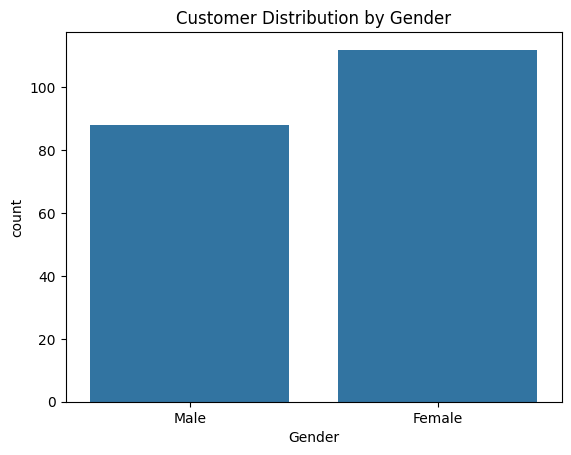

In [11]:
sns.countplot(data=df, x="Gender")
plt.title("Customer Distribution by Gender")
plt.show()

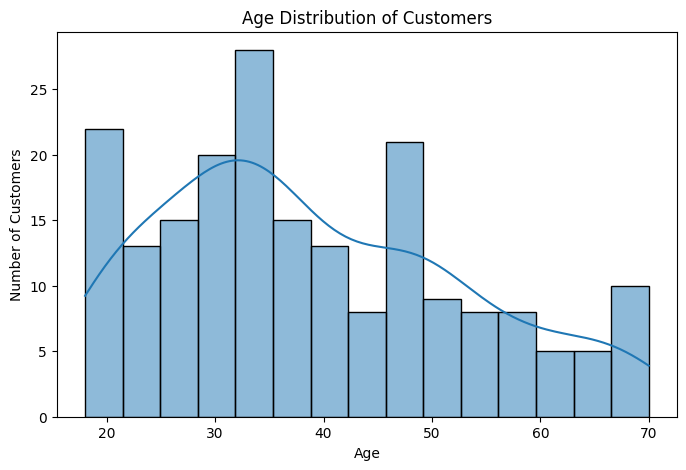

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(df["Age"], bins=15, kde=True)

plt.title("Age Distribution of Customers")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.show()

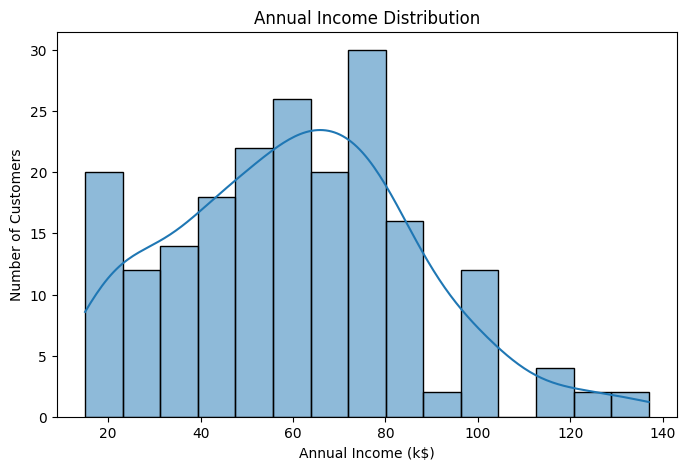

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(df["Annual Income (k$)"], bins=15, kde=True)

plt.title("Annual Income Distribution")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Number of Customers")
plt.show()

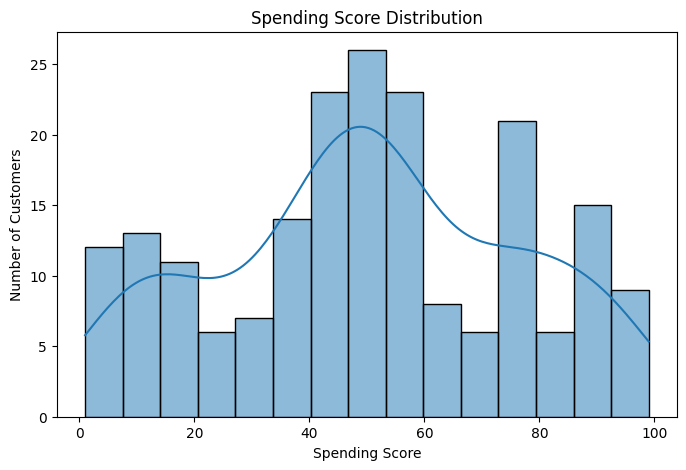

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(df["Spending Score (1-100)"], bins=15, kde=True)

plt.title("Spending Score Distribution")
plt.xlabel("Spending Score")
plt.ylabel("Number of Customers")
plt.show()

In [15]:
X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [16]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Data standardized successfully!")

Data standardized successfully!


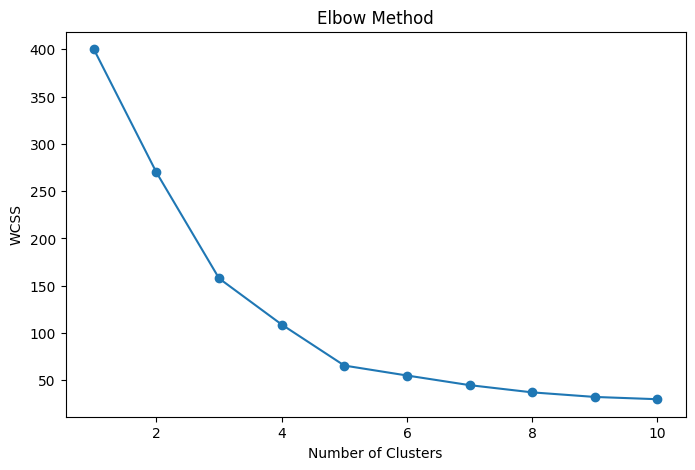

In [17]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(1, 11), wcss, marker="o")

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.show()

In [18]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(X_scaled)

print("Customer segmentation completed!")

Customer segmentation completed!


In [19]:
df.head(10)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4
5,6,Female,22,17,76,2
6,7,Female,35,18,6,4
7,8,Female,23,18,94,2
8,9,Male,64,19,3,4
9,10,Female,30,19,72,2


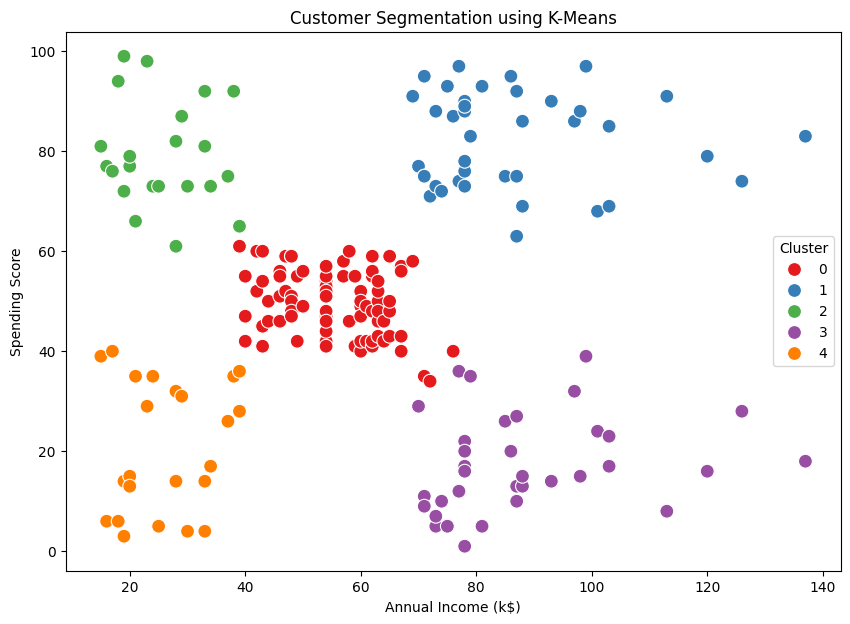

In [20]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Cluster",
    palette="Set1",
    s=100
)

plt.title("Customer Segmentation using K-Means")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")
plt.legend(title="Cluster")

plt.show()

In [21]:
cluster_summary = df.groupby("Cluster")[
    ["Age", "Annual Income (k$)", "Spending Score (1-100)"]
].mean()

cluster_summary

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,42.716049,55.296296,49.518519
1,32.692308,86.538462,82.128205
2,25.272727,25.727273,79.363636
3,41.114286,88.200000,17.114286
4,45.217391,26.304348,20.913043


In [22]:
cluster_counts = df["Cluster"].value_counts().sort_index()

print(cluster_counts)

Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


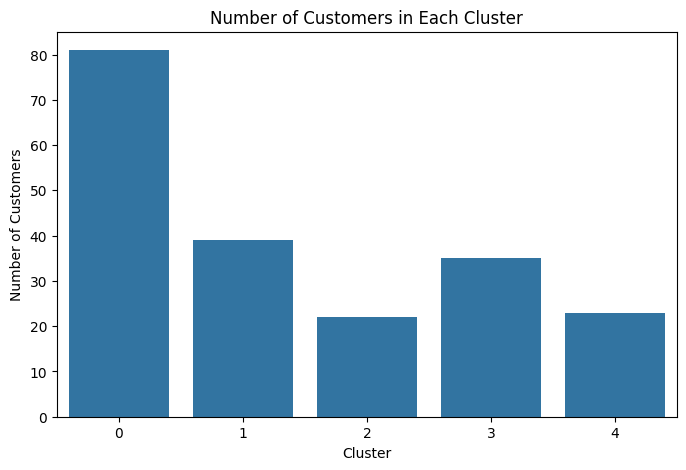

In [23]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="Cluster")

plt.title("Number of Customers in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")

plt.show()

In [25]:
from sklearn.metrics import silhouette_score

X_cluster = df[["Annual Income (k$)", "Spending Score (1-100)"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

score = silhouette_score(X_scaled, clusters)

print("Silhouette Score:", round(score, 3))

Silhouette Score: 0.555


In [26]:
df.to_csv("customer_segmentation_results.csv", index=False)

print("Customer segmentation results saved successfully!")

Customer segmentation results saved successfully!


In [27]:
df.head(10)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4
5,6,Female,22,17,76,2
6,7,Female,35,18,6,4
7,8,Female,23,18,94,2
8,9,Male,64,19,3,4
9,10,Female,30,19,72,2


In [28]:
cluster_summary = df.groupby("Cluster")[
    ["Age", "Annual Income (k$)", "Spending Score (1-100)"]
].mean().round(2)

cluster_summary

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,42.72,55.30,49.52
1,32.69,86.54,82.13
2,25.27,25.73,79.36
3,41.11,88.20,17.11
4,45.22,26.30,20.91


In [29]:
cluster_counts = df["Cluster"].value_counts().sort_index()

print("Number of customers in each cluster:")
print(cluster_counts)

Number of customers in each cluster:
Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


In [30]:
segment_names = {
    0: "Average Customers",
    1: "High-Value Customers",
    2: "Young High-Spending Customers",
    3: "High-Income Low-Spending Customers",
    4: "Low-Income Low-Spending Customers"
}

df["Segment"] = df["Cluster"].map(segment_names)

df.head(10)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster,Segment
0,1,Male,19,15,39,4,Low-Income Low-Spending Customers
1,2,Male,21,15,81,2,Young High-Spending Customers
2,3,Female,20,16,6,4,Low-Income Low-Spending Customers
3,4,Female,23,16,77,2,Young High-Spending Customers
4,5,Female,31,17,40,4,Low-Income Low-Spending Customers
5,6,Female,22,17,76,2,Young High-Spending Customers
6,7,Female,35,18,6,4,Low-Income Low-Spending Customers
7,8,Female,23,18,94,2,Young High-Spending Customers
8,9,Male,64,19,3,4,Low-Income Low-Spending Customers
9,10,Female,30,19,72,2,Young High-Spending Customers


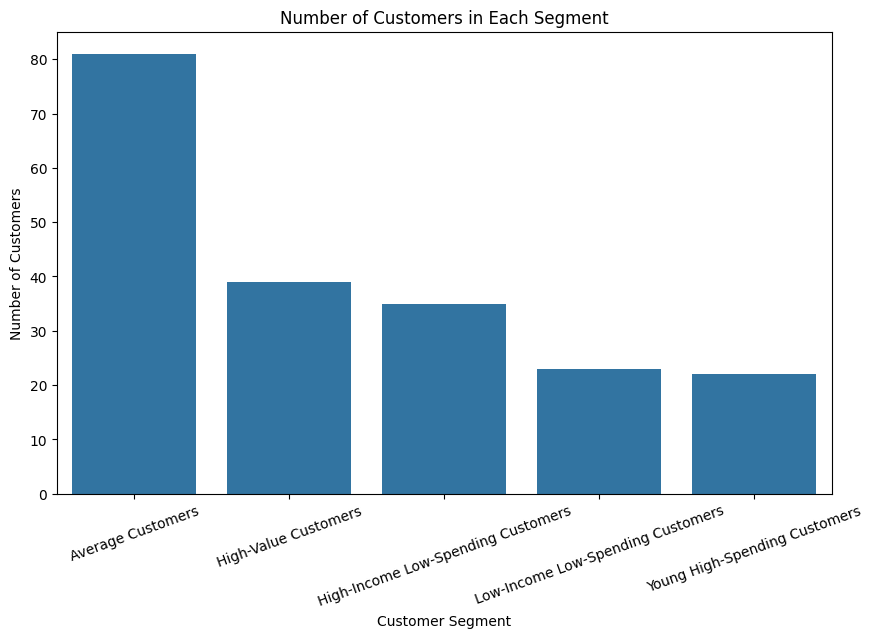

In [31]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="Segment",
    order=df["Segment"].value_counts().index
)

plt.title("Number of Customers in Each Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)
plt.show()

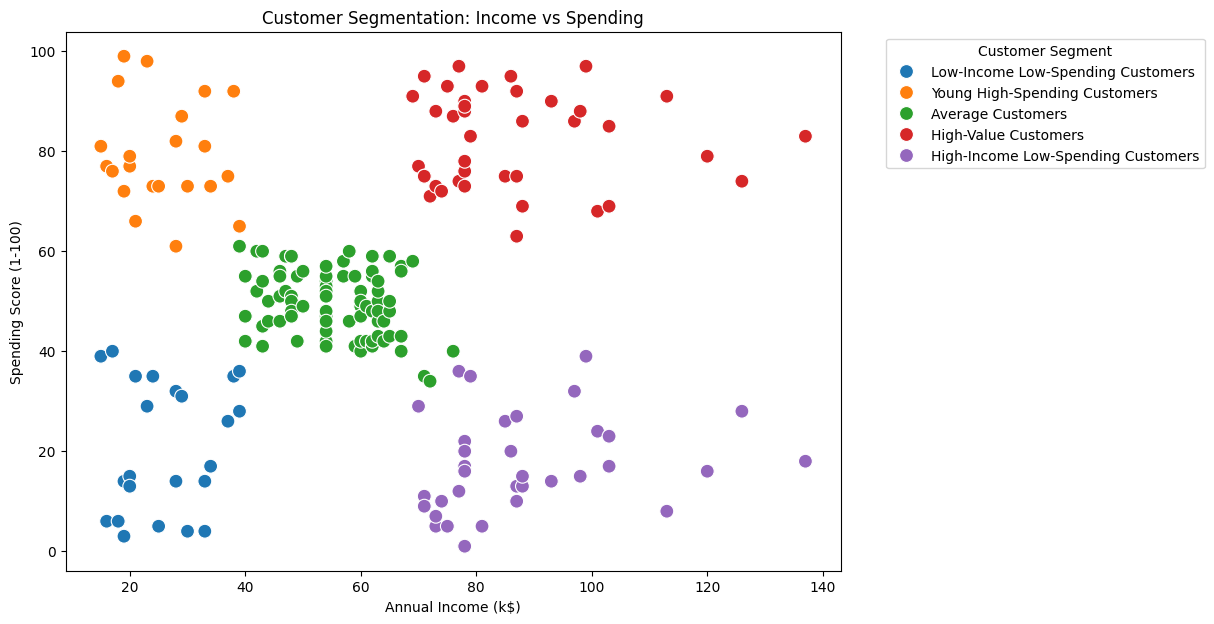

In [32]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Segment",
    s=100
)

plt.title("Customer Segmentation: Income vs Spending")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend(title="Customer Segment", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

## Business Insights

1. **Average Customers**
   - This is the largest customer segment with 81 customers.
   - These customers have moderate income and moderate spending scores.
   - Regular offers and loyalty programs can help maintain their engagement.

2. **High-Value Customers**
   - This segment contains 39 customers.
   - They have high annual income and high spending scores.
   - Premium offers and personalized promotions can be used to retain these customers.

3. **Young High-Spending Customers**
   - This segment contains 22 customers.
   - They have relatively lower income but high spending scores.
   - Trend-based products, discounts, and digital marketing may attract this group.

4. **High-Income Low-Spending Customers**
   - This segment contains 35 customers.
   - They have high income but low spending scores.
   - Personalized offers and targeted campaigns could encourage higher engagement.

5. **Low-Income Low-Spending Customers**
   - This segment contains 23 customers.
   - They have lower income and low spending scores.
   - Budget-friendly products and discounts may be more suitable for this group.

In [33]:
df.to_csv("customer_segmentation_final.csv", index=False)

print("Final customer segmentation file saved successfully!")

Final customer segmentation file saved successfully!


## Conclusion

The Customer Segmentation Project successfully grouped customers into five distinct segments using the K-Means clustering algorithm.

The segmentation was based on customers' annual income and spending score. The analysis identified different customer behaviors, including average customers, high-value customers, young high-spending customers, high-income low-spending customers, and low-income low-spending customers.

These segments can help businesses understand customer behavior, create targeted marketing strategies, improve customer engagement, and develop personalized offers.

Overall, this project demonstrates the practical use of Python, Pandas, Scikit-learn, Matplotlib, and Seaborn for customer analytics and unsupervised machine learning.